# Workshop - III

## Objective:
In this module, we will train and evaluate machine learning models to classify butterflies using an image dataset.

- **1. Exploratory Data Analysis (EDA):**
  - **Basic Information:**
    - Importing the necessary libraries & modules.
    - Loading the data.

  - **Examine Target Variable:**
      - Analyze class distribution.
      - Visualize data.

- **2. Data Preprocessing:**
  - **Image Augmentation:**
    - Random rotations, flips, zooms, and brightness adjustments.
    - Ensure balanced augmentation across classes.
    
  - **Data Splitting:**
    - Train-Validation-Test split.

  - **Image dataset creation:**
    - Create image dataset by applying scaling and transformations.

- **3. Model Training and Evaluation:**
  - **Train and evaluate different classification models:**
    - Feedforward Neural Network (FNNs):
    - Convolutional Neural Network (CNNs).

  - **Transfer Learning:**
    - Use pretrained models like ResNet50 or MobileNet.

  - **Compare models:**
    - Accuracy

#1. Exploratory Data Analysis (EDA)



## 1.1 Basic Information

<center><img src="https://i.natgeofe.com/k/9acd2bad-fb0e-43a8-935d-ec0aefc60c2f/monarch-butterfly-grass.jpg?wp=1&w=1084.125&h=609" width=500/></center>

**Problem Statement:**

Develop a model that classifies images of butterflies into 75 different categories based on their features. The dataset includes over 1,000 labeled images, divided into training and validation sets. Each image belongs to a single butterfly category.

The labels for the training images are provided in the Training_set.csv file. The Testing_set.csv contains the names of images in the test folder for which you need to predict the corresponding butterfly category

**Dataset:**
Dataset is taken from kaggle - <a href='https://www.kaggle.com/datasets/phucthaiv02/butterfly-image-classification'>link</a>

**Note:** The dataset is huge so it will take time to train the modles

## 1.1.1 Importing the necessary libraries & modules

In [ ]:
# Import the warnings module, which allows control over warning messages
import warnings

# Suppress all warnings in the script
warnings.filterwarnings("ignore")


In [ ]:
# === Standard Library Imports ===
import os  # For interacting with the operating system (e.g., file paths)

# === Data Handling and Manipulation ===
import pandas as pd  # For handling and manipulating datasets
import numpy as np  # For numerical operations

# === Data Visualization ===
import matplotlib.pyplot as plt  # For creating static visualizations
import seaborn as sns  # For enhanced data visualizations (e.g., heatmaps)

# === Machine Learning Utilities ===
from sklearn.model_selection import train_test_split  # For splitting data into train/test sets
from sklearn.metrics import classification_report, confusion_matrix  # For evaluating classification performance

# === Deep Learning Libraries ===
import tensorflow as tf  # TensorFlow for deep learning
from tensorflow.keras import layers, models  # Core TensorFlow Keras layers and model building tools
from tensorflow.keras.models import Sequential  # For creating sequential models
from tensorflow.keras.preprocessing.image import ImageDataGenerator  # For image augmentation and loading
from tensorflow.keras.preprocessing.image import load_img, img_to_array  # For loading and converting images

# === CNN Model Components ===
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense  # Core CNN layers
from tensorflow.keras.layers import Dropout, BatchNormalization, GlobalAveragePooling2D  # Advanced layers for regularization and optimization

# === Pre-trained Model Import ===
from tensorflow.keras.applications import VGG16  # Importing the VGG16 model for transfer learning

# === Regularization ===
from tensorflow.keras import regularizers  # For adding regularization to the model


In [ ]:
!pip install wget


## 1.1.2 Loading the data

- `read_csv()` helps to load a csv file.
- `head()` helps to view the initial few rows of the dataset.

In [4]:
# Load the dataset from a CSV file into a DataFrame
df = pd.read_csv('archive/Training_set.csv')
df_test = pd.read_csv('archive/Testing_set.csv')

# Display the first five rows of the DataFrame to get an initial overview of the data


In [5]:
df.head(10)



,filename,label
0,Image_1.jpg,SOUTHERN DOGFACE
1,Image_2.jpg,ADONIS
2,Image_3.jpg,BROWN SIPROETA
3,Image_4.jpg,MONARCH
4,Image_5.jpg,GREEN CELLED CATTLEHEART
5,Image_6.jpg,CAIRNS BIRDWING
6,Image_7.jpg,GREEN CELLED CATTLEHEART
7,Image_8.jpg,EASTERN DAPPLE WHITE
8,Image_9.jpg,BROWN SIPROETA
9,Image_10.jpg,RED POSTMAN


In [ ]:
df_test.head(10)


,filename
0,Image_1.jpg
1,Image_2.jpg
2,Image_3.jpg
3,Image_4.jpg
4,Image_5.jpg
5,Image_6.jpg
6,Image_7.jpg
7,Image_8.jpg
8,Image_9.jpg
9,Image_10.jpg


## 1.2 Examine Target Variable

## 1.2.1 Analyze class distribution

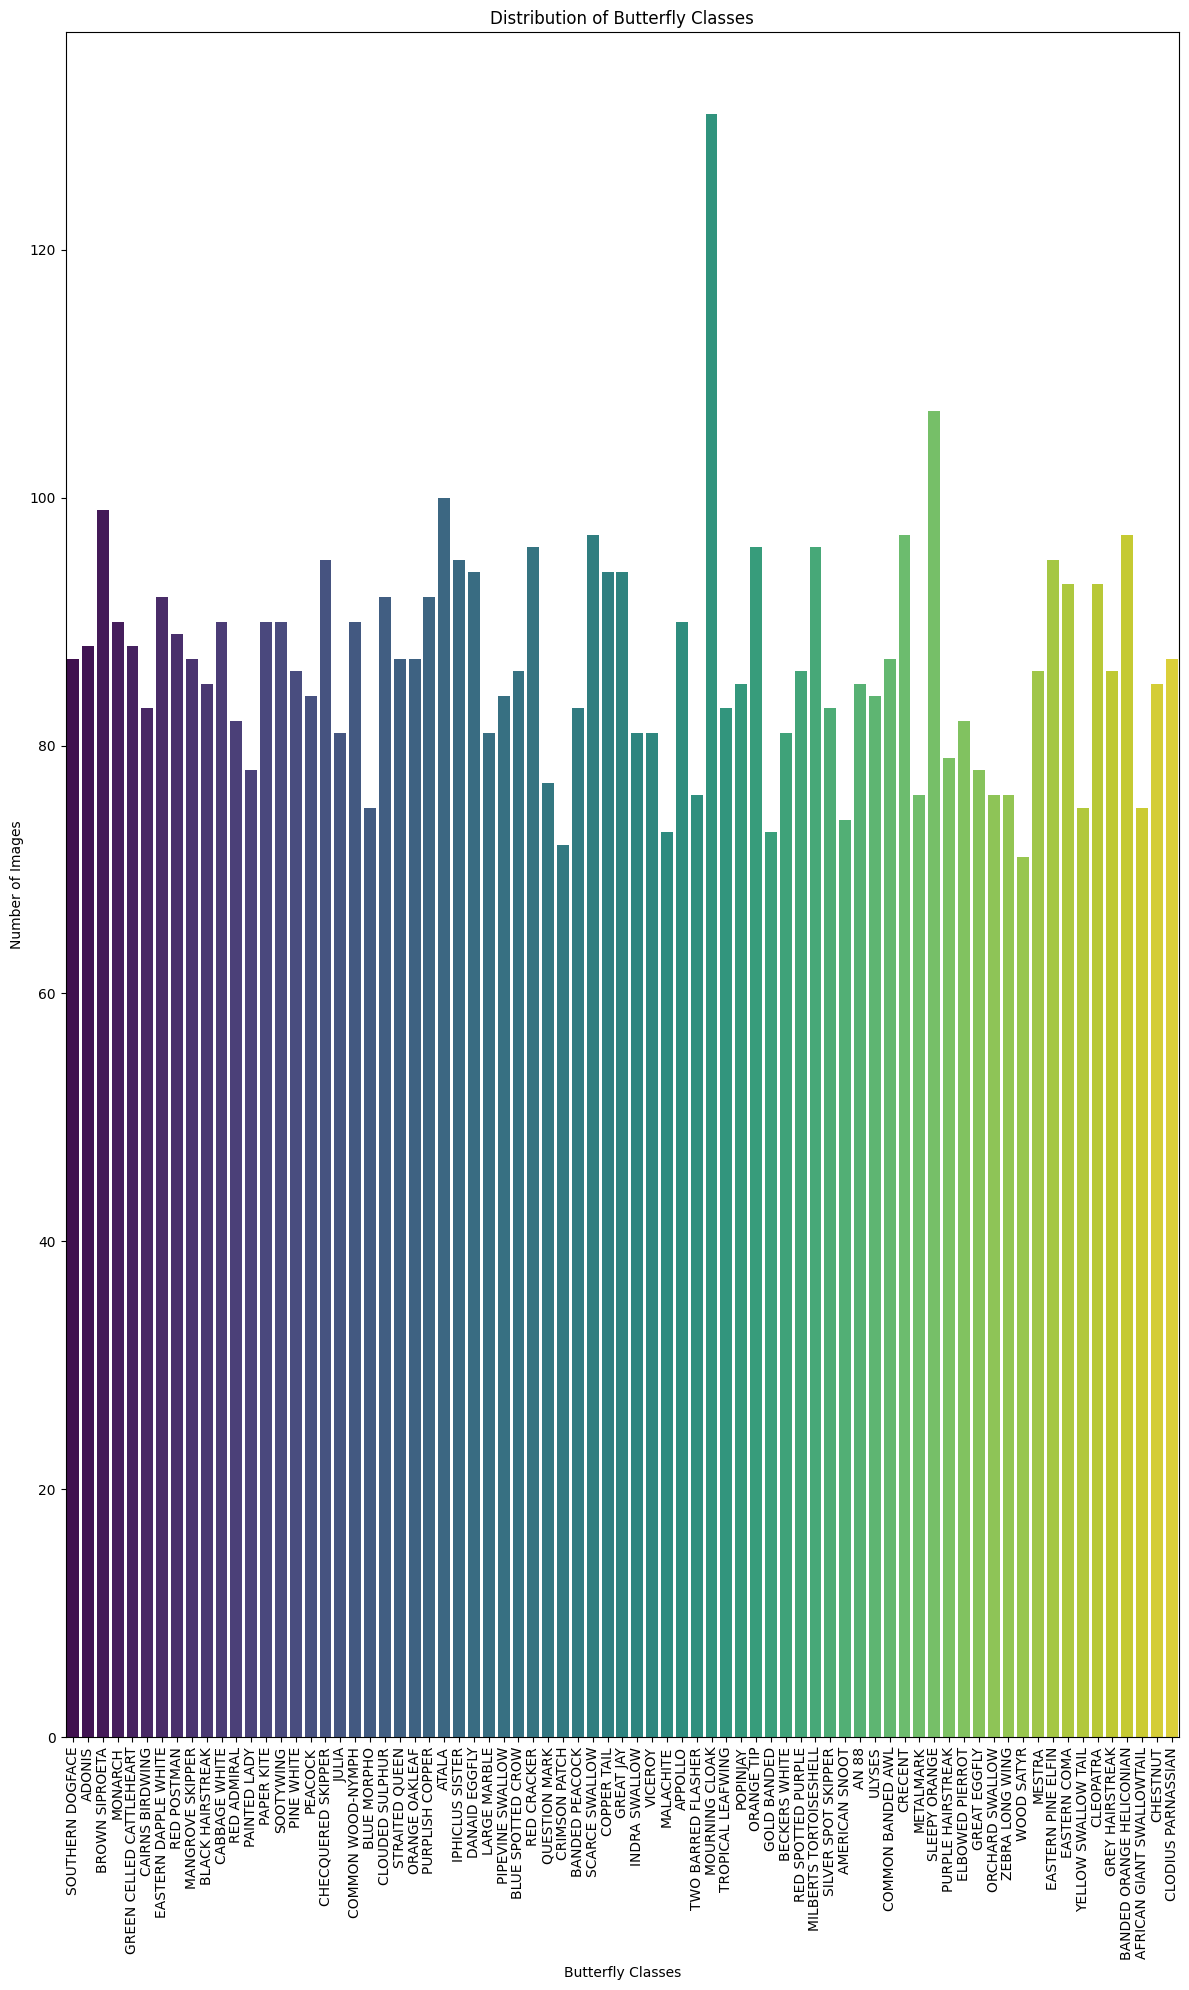

In [ ]:
# Count the number of occurrences for each class label and sort them by index (class order)
labels = {}

for i ,y in enumerate(df['label']):
  if y in labels:
    labels[y] += 1
  else:
    labels[y] = 1

label_list = [i for i in labels.keys()]


# Set the figure size for the plot

plt.figure(figsize=(12, 20))
# Create a bar plot to visualize the distribution of butterfly classes
sns.barplot(x=list(labels.keys()), y=list(labels.values()), palette='viridis')


# Add a title to the plot
plt.title('Distribution of Butterfly Classes')

# Label the x-axis with 'Butterfly Classes'
plt.xlabel('Butterfly Classes')

# Label the y-axis with 'Number of Images'
plt.ylabel('Number of Images')

# Rotate the x-axis labels for better readability (useful if the class names are long or numerous)
plt.xticks(rotation=90)

# Adjust the layout to ensure everything fits within the figure
plt.tight_layout()

# Display the plot
plt.show()


## Interpretation:

- Do we have major class imbalance?
  

## 1.2.2 Visualize data

['Image_6499.jpg', 'Image_6498.jpg', 'Image_6497.jpg', 'Image_6496.jpg', 'Image_6495.jpg', 'Image_6494.jpg']
archive/train/Image_6499.jpg
archive/train/Image_6498.jpg
archive/train/Image_6497.jpg
archive/train/Image_6496.jpg
archive/train/Image_6495.jpg
archive/train/Image_6494.jpg


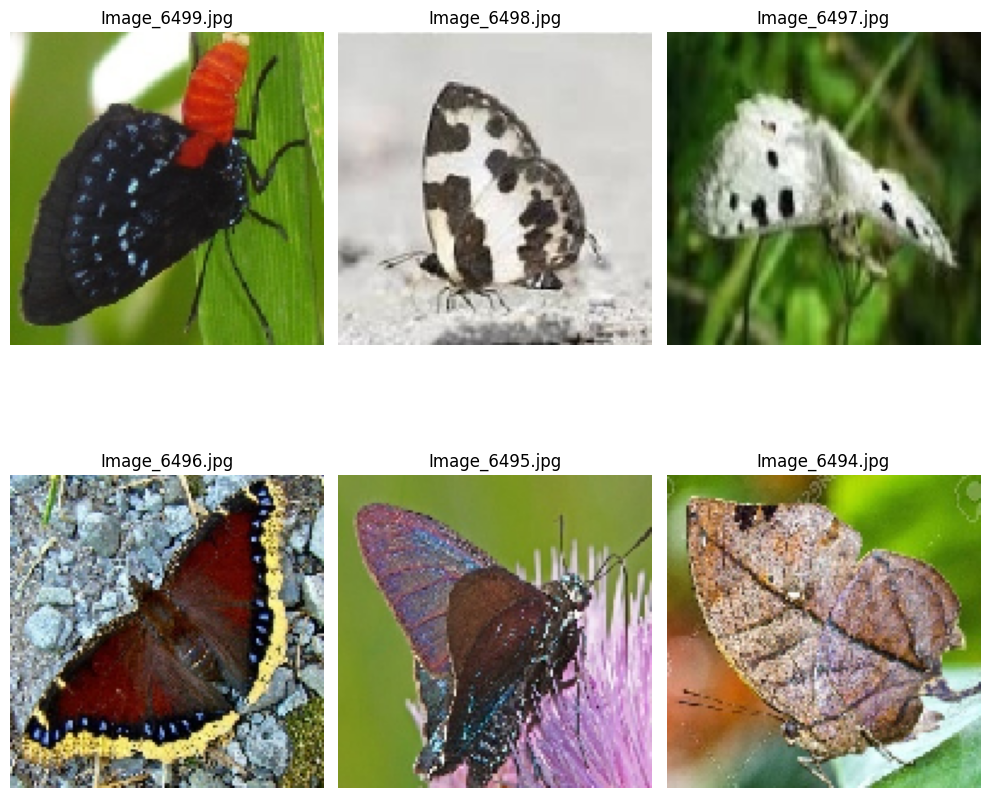

In [ ]:
# Define the directory and limit the filenames to 6 images
image_dir = "archive/train/"
filenames = [f"Image_{i}.jpg" for i in range( 6499,6493, -1)]  # Generate only 6 filenames
print(filenames)

# Set up the plot with a fixed 2x3 grid (6 images)
fig, axes = plt.subplots(2, 3, figsize=(10, 10))  # 2 rows, 3 columns
axes = axes.ravel()  # Flatten axes array for easier indexing


for i, filename in enumerate(filenames):
    img_path = os.path.join(image_dir, filename)  # Full path to the image
    print(img_path)  # Print the file path

    img = load_img(img_path, target_size=(130, 130))  # Load and resize the image
    img_array = img_to_array(img) / 255.0  # Normalize pixel values

    ax = axes[i]  # Get subplot position
    ax.imshow(img_array)  # Display the image
    ax.set_title(f"{filename}")  # Set the title as the filename
    ax.axis('off')  # Remove axis for cleaner visuals

# Hide any unused subplots (not needed here as we are displaying exactly 6 images)
for j in range(len(filenames), len(axes)):
    axes[j].axis('off')

plt.tight_layout()  # Ensure proper spacing
plt.show()  # Display the grid


## Interpretation:
- Are images grayscale or RGB?



- How RGB image will help in prediction?



# 2. Data Preprocessing

## 2.1 Data Splitting

 Data splitting refers to the process of dividing a dataset into separate subsets to ensure that a machine learning model is trained, validated, and tested effectively. Typically, the data is split into three main parts:

- **Training Set:** Used to train the model, where the model learns patterns and relationships in the data.
- **Validation Set:** Used to fine-tune model hyperparameters and evaluate performance during training.
- **Test Set:** Used to evaluate the final performance of the model on unseen data, providing an unbiased assessment of its predictive capabilities.

In [8]:
# Split into train (70%) and temp (30%) [temp will be further split into val and test]

train_images, temp_images = train_test_split(
    df, test_size=0.3, random_state=42, stratify=df['label']
)

# Split the temp dataset into validation (20%) and test (10%)
val_images, test_images = train_test_split(
    temp_images, test_size=0.5, random_state=42, stratify=temp_images['label']
)
print(f"Training set size: {len(train_images)}")
print(f"Validation set size: {len(val_images)}")
print(f"Test set size: {len(test_images)}")


Training set size: 4549
Validation set size: 975
Test set size: 975


## 2.2 Image dataset creation

The train_datagen object is an instance of the ImageDataGenerator class from TensorFlow/Keras, which is used for data augmentation in image datasets. Data augmentation involves applying random transformations to training images to artificially expand the dataset and improve the model's generalization.

Image augmentation help the model generalize better by simulating variations in real-world data, thus reducing overfitting. Common augmentation techniques include:

- **Rotation:** Randomly rotating images to account for different orientations.
- **Flipping:** Horizontally or vertically flipping images.
- **Zooming:** Randomly zooming in or out on parts of the image.
- **Shifting:** Randomly shifting the image along the width or height.
- **Brightness Adjustment:** Varying the brightness to simulate lighting changes.

In the provided code, ImageDataGenerator applies such transformations during training. It ensures that the model sees diverse variations of the images at every epoch, improving robustness and performance.



In [ ]:
image_dir = 'archive/train/'

# Data augmentation for training images to improve model generalization
train_datagen = ImageDataGenerator(
    rescale=1./255,               # Normalize pixel values to [0, 1]
    rotation_range=40,            # Randomly rotate images by up to 40 degrees
    width_shift_range=0.2,        # Randomly shift images horizontally by 20% of width
    height_shift_range=0.2,       # Randomly shift images vertically by 20% of height
    shear_range=0.2,              # Apply random shearing transformations
    zoom_range=0.2,               # Randomly zoom in or out by 20%
    horizontal_flip=True,         # Randomly flip images horizontally
    fill_mode='nearest'           # Fill missing pixels with the nearest pixel values
)


# Generate batches of augmented training data
train_generator = train_datagen.flow_from_dataframe(
    dataframe=train_images,       # Training dataset
    directory=image_dir,          # Path to images
    x_col='filename',             # Column with image file names
    y_col='label',                # Column with corresponding labels
    target_size=(150, 150),       # Resize images to 150x150
    batch_size=32,                # Number of images per batch
    class_mode='categorical'      # Labels are categorical
)


Found 4549 validated image filenames belonging to 75 classes.


In [ ]:
# Data generator for test images (no augmentation, only normalization)


test_datagen =  ImageDataGenerator(rescale=1./255
                )  # Normalize pixel values to [0, 1]

# Generate batches of test data
test_generator = test_datagen.flow_from_dataframe(
    dataframe= test_images,
    directory= image_dir,          # Path to test images
    x_col='filename',
    y_col='label',
    target_size=(150, 150),
    batch_size=32,
    class_mode='categorical'
)


Found 975 validated image filenames belonging to 75 classes.


In [ ]:
# Data generator for validation images (no augmentation, only normalization)
val_datagen = ImageDataGenerator(rescale=1./255)  # Normalize pixel values to [0, 1]

# Generate batches of validation data
val_generator = val_datagen.flow_from_dataframe(
    dataframe= val_images,
    directory= image_dir,          # Path to test images
    x_col='filename',
    y_col='label',
    target_size=(150, 150),
    batch_size=32,
    class_mode='categorical'
)


Found 975 validated image filenames belonging to 75 classes.


##Interpretation

- What is the purpose of the dataframe parameter in `flow_from_dataframe`?
    The dataframe parameter (val_df) provides the validation dataset, which includes the filenames and corresponding labels for generating image batches during validation.

- What does the directory parameter specify?
    The directory parameter (image_dir) specifies the path where the image files are stored. This path is combined with filenames from the x_col to locate the images.
  
- What is the role of the `x_col` and `y_col` parameters?
    The x_col (filename) indicates the column in the DataFrame containing image file names.
    The y_col (label) specifies the column with the corresponding labels for these images.
  

- Why is the target_size parameter used, and what does its value signify?
    The target_size parameter resizes all images to (150, 150) pixels to ensure consistency in input dimensions for the model.
- What does the batch_size parameter control?
    The batch_size parameter (32) determines the number of images processed together in a single batch during validation.
  

- What does the `class_mode` parameter define, and why is it set to categorical?
    The class_mode parameter specifies the format of the labels. It is set to categorical because the labels represent multiple classes (e.g., for multiclass classification).
  

- Why is data augmentation applied during training but not during validation?
    Data augmentation is used during training to artificially increase the diversity of the dataset by applying transformations like rotation, flipping, zooming, and shifting. This helps the model generalize better to unseen data and reduces overfitting.
    In contrast, validation data is kept unaugmented to ensure an unbiased evaluation of the model's performance on consistent, real-world-like data.

  

- What is the output of the `flow_from_dataframe` function?
    The function generates batches of image data (resized to 150x150) and their corresponding labels in one-hot-encoded format, ready for input into a model.

- Why is the use of `flow_from_dataframe` advantageous in this context?
    It allows for dynamic loading of images in batches directly from filenames in a DataFrame, reducing memory usage and simplifying the integration of labels and image data.
  

- How does this setup ensure compatibility with the model’s input requirements?
    By resizing images to a uniform size (150x150), batching data (32 per batch), and one-hot encoding labels (categorical), the generator ensures compatibility with models expecting fixed-size inputs and categorical labels.
  

# 3. Model Training and Evaluation

This phase involves using the prepared datasets (training, validation, and test) to train the model on the training set, monitor its performance on the validation set, and assess its final accuracy on the test set. The goal is to optimize the model's ability to generalize to unseen data while minimizing overfitting. Metrics such as accuracy, precision, recall, and loss are used to evaluate the model's performance.

## 3.1 Fully Connected Neural Network (FNN)

An FNN is a type of artificial neural network where each neuron in one layer is connected to every neuron in the next layer. It is composed of an input layer, one or more hidden layers, and an output layer. FNNs are used for various tasks, including classification and regression, by learning patterns from the input data through weighted connections and non-linear activation functions.



In [ ]:


# Define the input image shape
input_shape = (150, 150, 3)

# Create the FNN model
model_FNN = Sequential([
    # Flatten the 3D input image into a 1D vector
    Flatten(input_shape=input_shape),

    # First Dense layer with 1024 neurons, Batch Normalization, and ReLU activation
    Dense(1024, activation='relu'),
    BatchNormalization(),
    Dropout(0.5),  # Dropout for regularization
    # Second Dense layer with 512 neurons, Batch Normalization, and ReLU activation
    Dense(512, activation='relu'),
    BatchNormalization(),
    Dropout(0.4),  # Dropout for regularization
    # Third Dense layer with 256 neurons, Batch Normalization, and ReLU activation
    Dense(256, activation='relu'),
    BatchNormalization(),
    Dropout(0.3),  # Dropout for regularization
    # Fourth Dense layer with 128 neurons, Batch Normalization, and ReLU activation
    Dense(128, activation='relu'),
    BatchNormalization(),
    Dropout(0.2),  # Dropout for regularization
    # Output layer with 75 neurons (for 75 classes) and softmax activation
    Dense(75, activation='softmax')
])

# Compile the model
model_FNN.compile(
    optimizer= 'adam', # Use 'adam'
    loss= 'categorical_crossentropy',  # Use 'categorical_crossentropy'
    metrics=['accuracy']           # Metrics to monitor
)

# Model summary
model_FNN.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 67500)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1024)           │    69,121,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1024)           │         4,096 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 512)            │       524,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 75)             │         9,675 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 69,827,403 (266.37 MB)

 Trainable params: 69,823,563 (266.36 MB)

 Non-trainable params: 3,840 (15.00 KB)

In [ ]:
history = model_FNN.fit(
    train_generator,
    steps_per_epoch=train_generator.samples // train_generator.batch_size,  # Total batches per epoch
    epochs=  50         ,  # Number of epochs for training
    validation_data=val_generator,  # Validation data
    validation_steps=val_generator.samples // val_generator.batch_size  # Total batches for validation
)


Epoch 1/50
142/142 ━━━━━━━━━━━━━━━━━━━━ 18s 108ms/step - accuracy: 0.0281 - loss: 4.5894 - val_accuracy: 0.0302 - val_loss: 4.8848
Epoch 2/50
142/142 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.0312 - loss: 4.4521 - val_accuracy: 0.0302 - val_loss: 4.8503
Epoch 3/50
142/142 ━━━━━━━━━━━━━━━━━━━━ 15s 102ms/step - accuracy: 0.0560 - loss: 4.0650 - val_accuracy: 0.0917 - val_loss: 3.6985
Epoch 4/50
142/142 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.0625 - loss: 3.6620 - val_accuracy: 0.0938 - val_loss: 3.6868
Epoch 5/50
142/142 ━━━━━━━━━━━━━━━━━━━━ 15s 105ms/step - accuracy: 0.0748 - loss: 3.8249 - val_accuracy: 0.1198 - val_loss: 3.4414
Epoch 6/50
142/142 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.0000e+00 - loss: 4.2659 - val_accuracy: 0.1177 - val_loss: 3.4442
Epoch 7/50
142/142 ━━━━━━━━━━━━━━━━━━━━ 16s 110ms/step - accuracy: 0.0797 - loss: 3.7192 - val_accuracy: 0.1417 - val_loss: 3.4200
Epoch 8/50
142/142 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.0938 - loss: 3.6446 - 

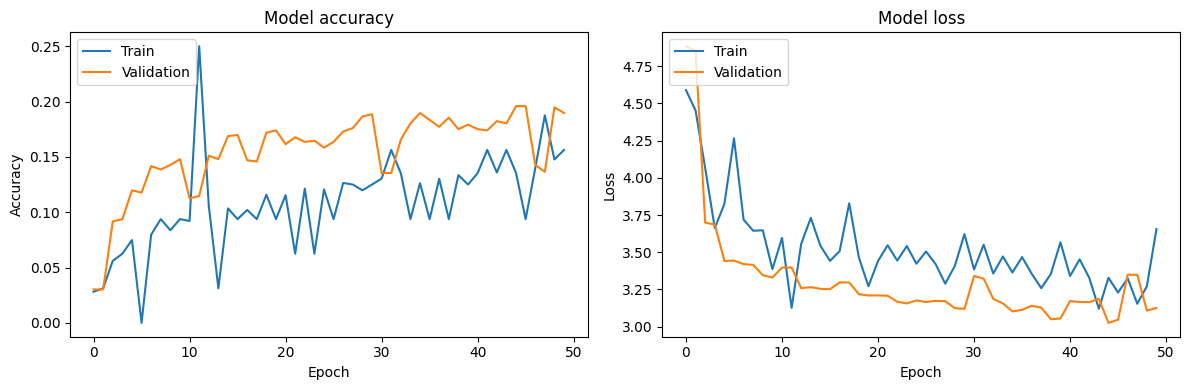

In [ ]:
plt.figure(figsize=(12, 4))  # Set the figure size for the plots

# Plot accuracy
plt.subplot(1, 2, 1)  # Create the first subplot (1 row, 2 columns, 1st plot)
plt.plot(history.history['accuracy'])  # Plot training accuracy over epochs
plt.plot(history.history['val_accuracy'])  # Plot validation accuracy over epochs
plt.title('Model accuracy')  # Set the title for the accuracy plot
plt.ylabel('Accuracy')  # Label for the y-axis
plt.xlabel('Epoch')  # Label for the x-axis
plt.legend(['Train', 'Validation'], loc='upper left')  # Add legend

# Plot loss
plt.subplot(1, 2, 2)  # Create the second subplot (1 row, 2 columns, 2nd plot)
plt.plot(history.history['loss'])  # Plot training loss over epochs
plt.plot(history.history['val_loss'])  # Plot validation loss over epochs
plt.title('Model loss')  # Set the title for the loss plot
plt.ylabel('Loss')  # Label for the y-axis
plt.xlabel('Epoch')  # Label for the x-axis
plt.legend(['Train', 'Validation'], loc='upper left')  # Add legend

plt.tight_layout()  # Adjust the layout to prevent overlapping
plt.show()  # Display the plots


In [ ]:
# Evaluate the model on the test set


31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - accuracy: 0.2072 - loss: 2.9286
Test Loss: 2.9286
Test Accuracy: 0.2072


##Interpretation

-##Interpretation

- What is the purpose of the input_shape parameter in the model?
  - The input_shape parameter ((150, 150, 3)) specifies the dimensions of the input images, which are resized to 150x150 pixels with 3 color channels (RGB).

- Why is the Flatten layer used at the beginning of the model?
  - The Flatten layer converts the 3D input image tensor into a 1D vector so it can be fed into the Dense layers for classification.

- What does the first Dense layer do, and why does it have 1024 neurons?
  - The first Dense layer performs a fully connected operation with 1024 neurons. The large number of neurons allows the model to learn high-level abstract features from the flattened input.

- What is the role of Batch Normalization in this model?
  - Batch Normalization normalizes the activations of the preceding layer, improving training speed and stability while reducing the risk of overfitting.

- Why is Dropout used, and how do the dropout rates vary across the layers?
  - Dropout is a regularization technique used to prevent overfitting by randomly deactivating a fraction of neurons during training.
  - Dropout rates decrease progressively: 0.5 → 0.4 → 0.3 → 0.2, allowing higher regularization in earlier layers and lower regularization in later layers to retain important features.

- Why does the output layer have 75 neurons and use softmax activation?
  - The output layer has 75 neurons to classify the input image into one of 75 classes.
  - Softmax activation converts the output into a probability distribution, with each neuron representing the probability of a specific class.

- Why is the categorical_crossentropy loss function used?
  - The categorical_crossentropy loss function is appropriate for multiclass classification tasks where labels are one-hot encoded.

- What does the Adam optimizer contribute to the model?
  - The Adam optimizer combines the advantages of RMSprop and SGD with momentum, adapting learning rates for each parameter to achieve efficient and stable training.

- How does the model monitor its performance during training?
  - The model monitors accuracy (metrics=['accuracy']) to evaluate how well it predicts the correct class during training and validation.

- What does the model_FNN.summary() function output?
  - The model_FNN.summary() function displays a summary of the model architecture, including the number of layers, output shapes of each layer, and the total number of trainable parameters.

- How does this architecture ensure feature extraction and classification?
  - The Flatten layer converts the image into a vector, Dense layers with Batch Normalization and Dropout extract and refine features, and the final Dense layer with softmax activation classifies the image into one of 75 categories.

- Why might this architecture struggle with high-resolution images?
  - This Fully Connected Neural Network (FNN) flattens the input image, which loses spatial relationships (e.g., pixel proximity).
  - High-resolution images would result in a very large input vector, increasing computational complexity and reducing efficiency.

  

## 3.2 Convolutional Neural Network (CNNs)

CNNs are a class of deep neural networks primarily used for processing structured grid data, such as images. They consist of layers that automatically learn spatial hierarchies of features using convolutions, pooling, and fully connected layers. CNNs are highly effective in tasks like image classification, object detection, and image segmentation due to their ability to capture patterns such as edges, textures, and shapes in images.

In [ ]:
model_CNN = models.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(150, 150, 3)),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(  128, (3, 3), activation='relu'),      
    layers.MaxPooling2D(   2,2        ),
    layers.Flatten(),
    layers.Dense(512, activation='relu'),
    layers.Dense(75, activation='softmax')
])

model_CNN.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])


model_CNN.summary()


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 34, 34, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 36992)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 512)            │    18,940,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 75)             │        38,475 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,072,139 (72.75 MB)

 Trainable params: 19,072,139 (72.75 MB)

 Non-trainable params: 0 (0.00 B)

##Interpretation

- How many convolutional layers are present in this CNN?

        The CNN has three convolutional layers:

            Conv2D with 32 filters.
            Conv2D with 64 filters.
            Conv2D with 128 filters.



- What is the purpose of the MaxPooling2D layers in this model?

    The MaxPooling2D layers are used to: Reduce the spatial dimensions of feature maps, making the model computationally efficient.
    Retain important features while discarding less relevant details.
  

- Why is the softmax activation used in the output layer?

    The softmax activation is used because this is a multi-class classification problem with 75 classes. It outputs probabilities for each class, summing up to 1.



- What is the role of the Flatten layer in this CNN?

    The Flatten layer converts the 2D feature maps from the convolutional layers into a 1D vector, which is required for the fully connected dense layers.

  

- What is the purpose of the optimizer in model compilation, and why is Adam used here?

    The optimizer adjusts the weights of the model to minimize the loss. Adam is used because it is computationally efficient and adapts the learning rate during training.


- What loss function is used, and why?
    The categorical crossentropy loss function is used because the task involves multi-class classification with one-hot encoded labels.

  

- How does the number of filters change in the convolutional layers, and why?

    The number of filters increases from 32 to 64, then to 128. This helps the model learn more complex and detailed features at deeper layers.

  

In [37]:
history = model_CNN.fit(train_generator, 
                        steps_per_epoch=train_generator.samples // train_generator.batch_size,
                        epochs=50,
                        validation_data=val_generator,
                        validation_steps=val_generator.samples )


Epoch 1/50
142/142 ━━━━━━━━━━━━━━━━━━━━ 27s 178ms/step - accuracy: 0.0686 - loss: 3.9535 - val_accuracy: 0.1426 - val_loss: 3.3649
Epoch 2/50
142/142 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.0938 - loss: 3.4929 - val_accuracy: 0.1374 - val_loss: 3.3993
Epoch 3/50
142/142 ━━━━━━━━━━━━━━━━━━━━ 27s 186ms/step - accuracy: 0.2001 - loss: 3.0762 - val_accuracy: 0.2851 - val_loss: 2.6096
Epoch 4/50
142/142 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.2188 - loss: 2.8241 - val_accuracy: 0.2851 - val_loss: 2.5811
Epoch 5/50
142/142 ━━━━━━━━━━━━━━━━━━━━ 26s 181ms/step - accuracy: 0.3017 - loss: 2.5845 - val_accuracy: 0.4113 - val_loss: 2.2024
Epoch 6/50
142/142 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.4062 - loss: 2.3781 - val_accuracy: 0.4103 - val_loss: 2.1854
Epoch 7/50
142/142 ━━━━━━━━━━━━━━━━━━━━ 27s 193ms/step - accuracy: 0.3892 - loss: 2.2240 - val_accuracy: 0.4626 - val_loss: 1.9869
Epoch 8/50
142/142 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.7500 - loss: 1.4218 - 

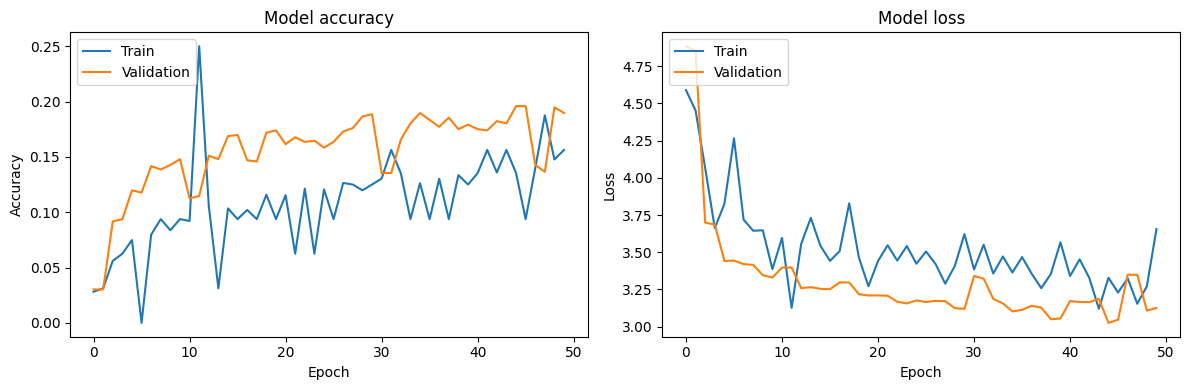

In [ ]:
plt.figure(figsize=(12, 4))  # Set the figure size for the plots

# Plot accuracy
plt.subplot(1, 2, 1)  # Create the first subplot (1 row, 2 columns, 1st plot)
plt.plot(history.history['accuracy'])  # Plot training accuracy over epochs
plt.plot(history.history['val_accuracy'])  # Plot validation accuracy over epochs
plt.title('Model accuracy')  # Set the title for the accuracy plot
plt.ylabel('Accuracy')  # Label for the y-axis
plt.xlabel('Epoch')  # Label for the x-axis
plt.legend(['Train', 'Validation'], loc='upper left')  # Add legend

# Plot loss
plt.subplot(1, 2, 2)  # Create the second subplot (1 row, 2 columns, 2nd plot)
plt.plot(history.history['loss'])  # Plot training loss over epochs
plt.plot(history.history['val_loss'])  # Plot validation loss over epochs
plt.title('Model loss')  # Set the title for the loss plot
plt.ylabel('Loss')  # Label for the y-axis
plt.xlabel('Epoch')  # Label for the x-axis
plt.legend(['Train', 'Validation'], loc='upper left')  # Add legend

plt.tight_layout()  # Adjust the layout to prevent overlapping
plt.show()  # Display the plots


## Interpretation:

- What can you infer about the training and validation accuracy trends?

  - Both training and validation accuracies improve steadily but start to plateau around epoch 30. This suggests the model is learning effectively but has reached its capacity.

- How does the validation accuracy compare to the training accuracy?

  - The validation accuracy closely tracks the training accuracy, indicating minimal overfitting.

- What does the steady increase in validation accuracy indicate?

  - It indicates the model generalizes well to unseen data.

- How does the training loss behave across epochs?

  - The training loss decreases steadily, which is expected as the model learns from the data.


  


## 3.3 Transfer Learning

**What is Transfer Learning?**

Transfer learning is a powerful technique in machine learning where a model trained on one task is reused or fine-tuned for a different, but related, task. It’s like borrowing knowledge from a pre-learned skill and applying it to a new one, saving time and resources.

### Everyday Analogy
Imagine you know how to ride a bicycle. When you learn to ride a motorbike, you don’t start from scratch. Your balance, coordination, and understanding of steering on a bicycle transfer over, making learning faster. Similarly, in transfer learning, a machine learning model transfers its knowledge from one domain to another.


### Why Use Transfer Learning?

1. **Saves Resources**: Training a machine learning model from scratch requires a lot of data and computational power. Transfer learning can significantly reduce this burden.
2. **Works with Small Datasets**: If you have a limited dataset for your new task, transfer learning allows you to use a pre-trained model that has already learned from a massive dataset.
3. **Improves Performance**: Pre-trained models often improve accuracy, especially in tasks like image recognition or natural language processing.



### How Does It Work?

1. **Pre-trained Model**: Start with a model that has already been trained on a large dataset for a similar task. For example:
   - **Image Recognition**: Models like ResNet or VGG trained on ImageNet.
   - **Text Processing**: Models like BERT or GPT trained on massive text corpora.

2. **Feature Extraction**: Use the pre-trained model's learned features (e.g., edges in images or word embeddings in text) and apply them directly to your task.

3. **Fine-Tuning**: Adjust the pre-trained model's parameters slightly to specialize it for your specific task. This step tailors the model to your data.



### Example: Cats vs. Dogs Classifier

1. **Pre-trained Model**: Start with a model like ResNet that has been trained on ImageNet, a dataset with millions of general images.
2. **Your Dataset**: You only have 1,000 images of cats and dogs.
3. **Process**:
   - Remove the pre-trained model's last layer (used for the original task, like classifying 1,000 general categories).
   - Add a new output layer specific to cats vs. dogs (2 categories).
   - Train the new layer with your dataset, while keeping most of the original layers unchanged or lightly fine-tuning them.



### Applications

1. **Image Recognition**: Identifying medical anomalies in X-rays using models pre-trained on general images.
2. **Natural Language Processing (NLP)**: Building a chatbot by fine-tuning GPT or BERT on your company's customer queries.
3. **Speech Recognition**: Customizing a speech-to-text model for a specific accent or language.



### Advantages

- **Faster Training**: Leveraging pre-trained models accelerates learning.
- **Better Performance**: Especially useful when data is scarce.
- **Reusable Knowledge**: Applies knowledge from one domain to another.



<center><img src="https://miro.medium.com/v2/resize:fit:1400/0*xNjEPIZmPvKeqss6" width=500 height=400/></center>



In [ ]:
# Define input shape and number of classes
input_shape = (150, 150, 3)
num_classes = 75


## In the provided code:

- **Pre-trained Model (VGG16):** The VGG16 model is initialized with weights from ImageNet, a large image dataset.
- **Layer Freezing:** The layers of the pre-trained model are frozen (base_model.trainable = False) to retain the learned features and prevent modifications during training on the new dataset. Only the newly added layers specific to the new task are trained.


In [ ]:
# Override default cache directory

# Initialize VGG16 model with pre-trained weights from ImageNet
base_model = VGG16(weights='imagenet', include_top=False, input_shape=input_shape)

# Freeze the layers of the pre-trained model to prevent training on them
base_model.trainable = False
#print(f"dataset path: {}")


## Architecture description

- The custom model is built on top of the pre-trained VGG16 model and adapted for the specific task using additional layers.
- This architecture leverages the feature extraction power of VGG16 while tailoring the top layers for the specific classification task.

In [ ]:
# Build the custom model
model_vgg = Sequential([
    # Add the base VGG16 model (without the top classification layers)
    base_model,

    # Add Global Average Pooling to reduce the spatial dimensions
    GlobalAveragePooling2D(),

    # Add a fully connected (Dense) layer
    Dense(512, activation='relu', kernel_regularizer=regularizers.l2(0.001))  ,

    # Dropout layer for regularization
    Dropout(0.5),  # Dropout for regularization,

    # Output layer with softmax activation for multi-class classification
    Dense(num_classes, activation='softmax')  # Output layer for 1000 classes

])


In [55]:
# Compile the model with an optimizer, loss function, and evaluation metrics
model_vgg.compile( optimizer='adam',  # Use the Adam optimizer
                loss='categorical_crossentropy',  # Use categorical cross-entropy loss for multi-class classification
                metrics=['accuracy']  # Monitor accuracy during training

)

# Model summary
model_vgg.summary()


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 4, 4, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_4      │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 75)             │        38,475 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,015,819 (57.28 MB)

 Trainable params: 301,131 (1.15 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

##Interpretation

- What is the purpose of setting base_model.trainable = False?

  - Freezing the base model prevents its pre-trained weights from being updated during training. This ensures the model leverages features learned from the ImageNet dataset while training only the custom layers on your dataset.

- Why is GlobalAveragePooling2D() used instead of Flatten()?

  - GlobalAveragePooling2D reduces the spatial dimensions of feature maps by taking the average of each channel, resulting in a fixed-size output. This helps prevent overfitting and reduces the number of trainable parameters.

- What is the role of the Dropout(0.5) layer?

  - The dropout layer randomly disables 50% of the neurons during each training step to prevent overfitting and improve generalization.

- What does weights='imagenet' indicate in the VGG16 initialization?

  - It loads the pre-trained weights of VGG16 from the ImageNet dataset, enabling transfer learning.

- Why is include_top=False specified?

  - It removes the fully connected (top) layers of VGG16 so the model can be customized for a new classification task with num_classes outputs.





In [ ]:

#Train the model using the data generators
history = model_vgg.fit(
    train_generator,
    steps_per_epoch=train_generator.samples // train_generator.batch_size,
    epochs=40,
    validation_data=val_generator,
    validation_steps=val_generator.samples // val_generator.batch_size
)


Epoch 1/40
142/142 ━━━━━━━━━━━━━━━━━━━━ 156s 1s/step - accuracy: 0.0950 - loss: 4.3113 - val_accuracy: 0.3302 - val_loss: 3.5124
Epoch 2/40
142/142 ━━━━━━━━━━━━━━━━━━━━ 26s 175ms/step - accuracy: 0.3438 - loss: 3.4770 - val_accuracy: 0.3198 - val_loss: 3.5087
Epoch 3/40
142/142 ━━━━━━━━━━━━━━━━━━━━ 141s 997ms/step - accuracy: 0.2801 - loss: 3.2874 - val_accuracy: 0.4958 - val_loss: 2.6236
Epoch 4/40
142/142 ━━━━━━━━━━━━━━━━━━━━ 25s 171ms/step - accuracy: 0.3750 - loss: 2.9478 - val_accuracy: 0.4938 - val_loss: 2.6251
Epoch 5/40
142/142 ━━━━━━━━━━━━━━━━━━━━ 144s 1s/step - accuracy: 0.3894 - loss: 2.7034 - val_accuracy: 0.5781 - val_loss: 2.1962
Epoch 6/40
142/142 ━━━━━━━━━━━━━━━━━━━━ 25s 171ms/step - accuracy: 0.5000 - loss: 2.3913 - val_accuracy: 0.5750 - val_loss: 2.1962
Epoch 7/40
142/142 ━━━━━━━━━━━━━━━━━━━━ 143s 1s/step - accuracy: 0.4543 - loss: 2.4179 - val_accuracy: 0.6115 - val_loss: 1.9927
Epoch 8/40
142/142 ━━━━━━━━━━━━━━━━━━━━ 25s 173ms/step - accuracy: 0.5625 - loss: 2.2214

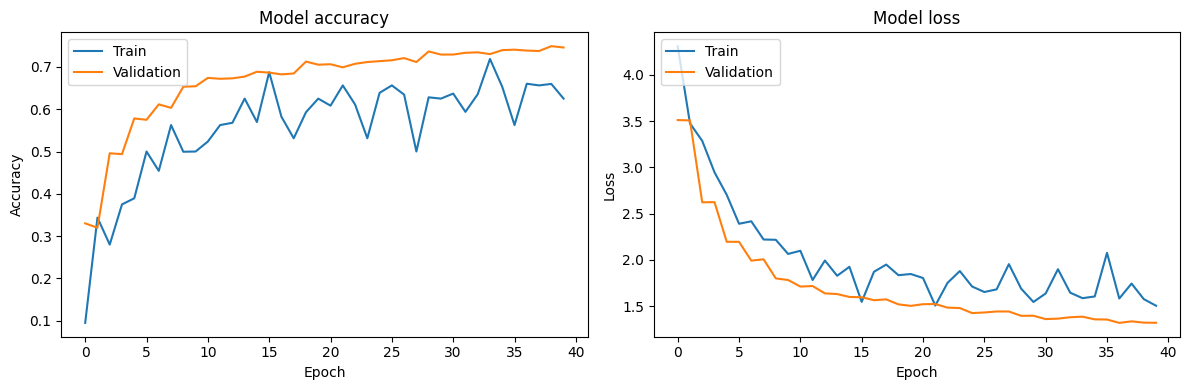

In [ ]:
plt.figure(figsize=(12, 4))  # Set the figure size for the plots

# Plot accuracy
plt.subplot(1, 2, 1)  # Create the first subplot (1 row, 2 columns, 1st plot)
plt.plot(history.history['accuracy'])  # Plot training accuracy over epochs
plt.plot(history.history['val_accuracy'])  # Plot validation accuracy over epochs
plt.title('Model accuracy')  # Set the title for the accuracy plot
plt.ylabel('Accuracy')  # Label for the y-axis
plt.xlabel('Epoch')  # Label for the x-axis
plt.legend(['Train', 'Validation'], loc='upper left')  # Add legend

# Plot loss
plt.subplot(1, 2, 2)  # Create the second subplot (1 row, 2 columns, 2nd plot)
plt.plot(history.history['loss'])  # Plot training loss over epochs
plt.plot(history.history['val_loss'])  # Plot validation loss over epochs
plt.title('Model loss')  # Set the title for the loss plot
plt.ylabel('Loss')  # Label for the y-axis
plt.xlabel('Epoch')  # Label for the x-axis
plt.legend(['Train', 'Validation'], loc='upper left')  # Add legend

plt.tight_layout()  # Adjust the layout to prevent overlapping
plt.show()  # Display the plots


##Interpretation

- What is the purpose of setting base_model.trainable = False?

  - Freezing the base model prevents its pre-trained weights from being updated during training. This ensures the model leverages features learned from the ImageNet dataset while training only the custom layers on your dataset.

- Why is GlobalAveragePooling2D() used instead of Flatten()?

  - GlobalAveragePooling2D reduces the spatial dimensions of feature maps by taking the average of each channel, resulting in a fixed-size output. This helps prevent overfitting and reduces the number of trainable parameters.

- What is the role of the Dropout(0.5) layer?

  - The dropout layer randomly disables 50% of the neurons during each training step to prevent overfitting and improve generalization.

- What does weights='imagenet' indicate in the VGG16 initialization?

  - It loads the pre-trained weights of VGG16 from the ImageNet dataset, enabling transfer learning.

- Why is include_top=False specified?

  - It removes the fully connected (top) layers of VGG16 so the model can be customized for a new classification task with num_classes outputs.


  

## 3.4 Compare models

To evaluate the performance of three different models trained on image data—FNN (Fully Connected Neural Network), CNN (Convolutional Neural Network), and a Transfer Learning model using VGG—we conducted a detailed analysis of their accuracy metrics. The results highlight the strengths and limitations of each model:

- **FNN (Fully Connected Neural Network):**
  - The FNN serves as a baseline model, relying solely on flattened image data as input.
  - Accuracy: The accuracy achieved was comparatively lower, as FNNs lack the capability to capture spatial and hierarchical patterns in images.
  - Insights: The performance suggests that FNNs are not well-suited for tasks where feature extraction from images is critical.

- **CNN (Convolutional Neural Network):**

  - CNNs are designed to process image data, utilizing convolutional layers to extract features and pooling layers to reduce dimensionality.
  - Accuracy: The CNN outperformed the FNN by a significant margin, thanks to its ability to detect spatial structures and patterns in the data.
  - Insights: The accuracy demonstrates that CNNs are more adept at handling image-related tasks by learning local features and patterns directly from the data.

- **Transfer Learning with VGG:**

  - Transfer learning leverages pre-trained weights from the VGG model, fine-tuning the network for the specific dataset.
  - Accuracy: The VGG-based model achieved the highest accuracy among the three, benefiting from pre-trained feature extraction layers trained on a large dataset (e.g., ImageNet).
  - Insights: This approach outshines others, especially when the dataset is limited, as the pre-trained model significantly accelerates training and improves accuracy by leveraging learned representations.

In [ ]:
def get_evaluation_metrics(model, test_generator):

    # 1. Evaluate the model on the test data (this will return loss and accuracy)
    test_loss, test_acc = model.evaluate(test_generator, steps=test_generator.samples // test_generator.batch_size)

    # 2. Make predictions on the test set
    # Predict the labels for the test dataset
    y_pred = model.predict(test_generator, steps=test_generator.samples // test_generator.batch_size, verbose=1)


In [ ]:
get_evaluation_metrics(model_FNN, train_generator)


142/142 ━━━━━━━━━━━━━━━━━━━━ 12s 85ms/step - accuracy: 0.1822 - loss: 3.1134
142/142 ━━━━━━━━━━━━━━━━━━━━ 11s 80ms/step


In [ ]:
get_evaluation_metrics(model_CNN, test_generator)


30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 43ms/step - accuracy: 0.0146 - loss: 4.3188
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 43ms/step


In [ ]:
get_evaluation_metrics(model_vgg, test_generator)


30/30 ━━━━━━━━━━━━━━━━━━━━ 24s 788ms/step - accuracy: 0.7458 - loss: 1.3212
30/30 ━━━━━━━━━━━━━━━━━━━━ 24s 802ms/step


## Conclusion

- What does the comparitive analysis reveal?

- Which is performing better FNN or CNN?

- What do you understand from Trnasfer Learning?


<hr> <hr>